<a href="https://colab.research.google.com/github/SambadRupakheti/Amazon-Grocery-and-Gourmet-Food-Reviews/blob/main/social_media_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Source 1: Open Food Facts**  
- **Description:** It contains nutritional information on a variety of food products.  
- **URL:** https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz  

**Data Source 2: Amazon Grocery and Gourmet Food Reviews**  
- **Description:** It contains user reviews and meta information for grocery products.
- **Review Data URL:** https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Grocery_and_Gourmet_Food.jsonl.gz  
- **Metadata URL:** https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/meta_categories/meta_Grocery_and_Gourmet_Food.jsonl.gz  

In [ ]:
!wget https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz

In [ ]:

!wget https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Grocery_and_Gourmet_Food.jsonl.gz
!wget https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/meta_categories/meta_Grocery_and_Gourmet_Food.jsonl.gz

In [ ]:
!gunzip -k "/kaggle/working/meta_Grocery_and_Gourmet_Food.jsonl.gz"
!rm -rf "/kaggle/working/meta_Grocery_and_Gourmet_Food.jsonl.gz"
!gunzip -k "/kaggle/working/Grocery_and_Gourmet_Food.jsonl.gz"
!rm -rf "/kaggle/working/Grocery_and_Gourmet_Food.jsonl.gz"
!gunzip -k "/kaggle/working/en.openfoodfacts.org.products.csv.gz"
!rm -rf "/kaggle/working/en.openfoodfacts.org.products.csv.gz"


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix,f1_score, precision_score, recall_score,roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import RFE

file_path = '/kaggle/working/en.openfoodfacts.org.products.csv'

# List of necessary columns (excluding the ones we don't need) and are selected by loading the dataset previously with small number of dataset around 100k and checking for the ones that are important
necessary_columns = [
    'code',
    'product_name',
    'brands',
    'nutriscore_grade',
    'pnns_groups_1',
    'pnns_groups_2',
    'energy-kcal_100g',
    'energy_100g',
    'fat_100g',
    'saturated-fat_100g',
    'carbohydrates_100g',
    'sugars_100g',
    'fiber_100g',
    'proteins_100g',
    'salt_100g',
    'sodium_100g'
]

df = pd.read_csv(
    file_path,
    sep='\t',
    encoding='utf-8',
    on_bad_lines='skip',
    low_memory=False,
    usecols=necessary_columns
)

print("DataFrame columns:", df.columns.tolist())
print(df.head())

DataFrame columns: ['code', 'product_name', 'brands', 'nutriscore_grade', 'pnns_groups_1', 'pnns_groups_2', 'energy-kcal_100g', 'energy_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g']
           code                              product_name          brands  \
0  000000000054             Limonade artisanale a la rose             NaN   
1  000000000063  Mozzarella Schnittfest Gerieben 45% Fett   Gut & Gunstig   
2  000000000114                             Chocolate n 3  Jeff de Bruges   
3      00000001         Wild Norwegian Elite Omega-3 Gems         Carlson   
4    0000000105      Paleta gran reserva - Sierra nevada-        AdvoCare   

  nutriscore_grade pnns_groups_1                     pnns_groups_2  \
0          unknown       unknown                           unknown   
1          unknown       unknown                           unknown   
2          unknown       unknown                      

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [ ]:
# Calculate the percentage of null values for each column
null_percentage = df.isnull().sum()
total_length=df.shape[0]

for value,column in zip(null_percentage,df.columns):
    print("{} {:.2f} %".format(column,value/total_length*100))

code 0.00 %
product_name 6.36 %
brands 40.30 %
nutriscore_grade 0.50 %
pnns_groups_1 0.49 %
pnns_groups_2 0.49 %
energy-kcal_100g 27.08 %
energy_100g 25.79 %
fat_100g 26.61 %
saturated-fat_100g 30.31 %
carbohydrates_100g 26.49 %
sugars_100g 29.26 %
fiber_100g 64.45 %
proteins_100g 26.47 %
salt_100g 35.94 %
sodium_100g 35.94 %


# Dropping missing values
 We choose to drop rows with missing entries. This method is simple and effective for large datasets.

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.describe()

,energy-kcal_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
count,7.650890e+05,765089.000000,765089.000000,7.650890e+05,765089.000000,7.650890e+05,7.650890e+05
mean,1.855993e+10,35.301611,13.895089,7.987626e+06,10.021091,1.046396e+08,4.185582e+07
std,1.623426e+13,976.832636,30.546545,6.986723e+09,163.000567,9.146062e+10,3.658425e+10
min,0.000000e+00,-1.000000,-1.450000,0.000000e+00,-12.600000,0.000000e+00,0.000000e+00
25%,1.110000e+02,6.100000,1.000000,0.000000e+00,2.200000,5.140000e-02,2.058824e-02
50%,2.730000e+02,22.700000,3.900000,1.600000e+00,6.580000,5.000000e-01,2.000000e-01
75%,4.170000e+02,56.666667,17.800000,3.900000e+00,12.120000,1.200000e+00,4.800000e-01
max,1.420000e+16,853555.000000,6875.000000,6.111242e+12,100000.000000,8.000000e+13,3.200000e+13


## Nutriscore Grade Distribution


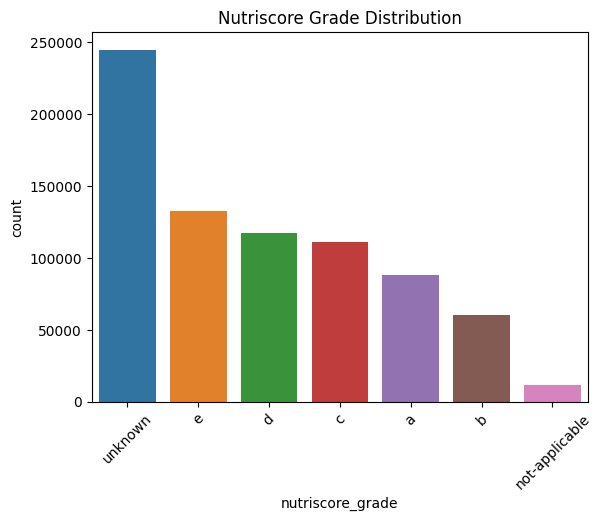

In [ ]:
#plotting number of product on each nutirional gardes to see if we have dataset with proper distribution of data
sns.countplot(data=df, x='nutriscore_grade', order=df['nutriscore_grade'].value_counts().index)
plt.title('Nutriscore Grade Distribution')
plt.xticks(rotation=45)
plt.show()

This bar chart shows the frequency of each Nutri-Score grade in the dataset. The largest category is labeled as “unknown,” indicating many products either have incomplete or missing Nutri-Score data. Among the known scores, grade “e” has the highest count, followed by “d,” “c,” “a,” and “b.” A small portion is marked as “not-applicable,” which may represent items that cannot be assigned a Nutri-Score. This distribution highlights potential data gaps and underscores the need for careful handling of unknown entries in further analyses.


## Top 10 Primary Food Groups

pnns_groups_1
unknown                    363756
Sugary snacks               83843
Cereals and potatoes        72812
Composite foods             42949
Beverages                   41423
Milk and dairy products     38077
Fish Meat Eggs              33111
Fat and sauces              32096
Fruits and vegetables       30185
Salty snacks                26128
Name: count, dtype: int64


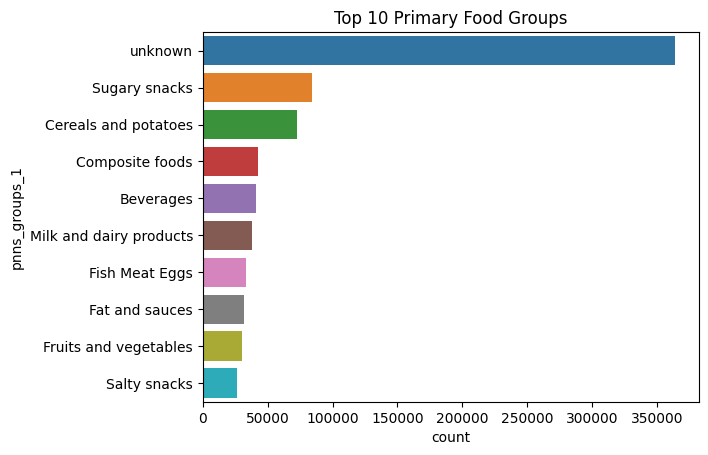

In [ ]:
#plotting different types of food available
print(df['pnns_groups_1'].value_counts().head(10))
sns.countplot(y='pnns_groups_1', data=df, order=df['pnns_groups_1'].value_counts().index[:10])
plt.title('Top 10 Primary Food Groups')
plt.show()


This bar chart shows that “unknown” dominates the distribution, indicating a significant amount of products that lack clear labeling. Among labeled categories, “Sugary snacks” and “Cereals and potatoes” appear most frequently, followed by others like “Composite foods” and “Beverages.” This discrepancy highlights the importance of careful data handling and suggests that refining or reclassifying the “unknown” entries may be necessary to draw more accurate insights from the dataset.


In [ ]:
#dropping Unknown and not-applicable column as we are planning on predicting the nutritional grade of the product
df = df[~df['nutriscore_grade'].isin(['unknown', 'not-applicable'])].reset_index(drop=True)
# df = df[~df['pnns_groups_1'].isin(['unknown',"Alcoholic beverages"])].reset_index(drop=True)


In [ ]:
df.shape

(508778, 16)

## One-Hot Encoding
We applied one-hot encoding to the pnns_groups_1 column to convert categorical values into a numeric format that machine learning algorithms can work with effectively.

In [ ]:
#encoding categorical column using one hot encoding methid and then
df_encoded = pd.get_dummies(df, columns=["pnns_groups_1"], prefix='', prefix_sep='', dtype=int)

zero_one_counts = df_encoded.apply(lambda col: col.value_counts()).fillna(0).astype(int)

# print(df_encoded.head())
print(zero_one_counts)


<ipython-input-10-78896abc0efe>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded = df_encoded.replace({True: 1, False: 0})


   Alcoholic beverages  Beverages  Cereals and potatoes  Composite foods  \
0               508734     469768                437455           466733   
1                   44      39010                 71323            42045   

   Fat and sauces  Fish Meat Eggs  Fruits and vegetables  \
0          478085          475776                 479207   
1           30693           33002                  29571   

   Milk and dairy products  Salty snacks  Sugary snacks  unknown  
0                   471027        482703         427920   390372  
1                    37751         26075          80858   118406  


In [ ]:
df = pd.concat([df, df_encoded], axis=1)

In [ ]:
encoded_columns=df_encoded.columns

In [ ]:
df.head()

,code,product_name,brands,nutriscore_grade,pnns_groups_1,pnns_groups_2,energy-kcal_100g,energy_100g,fat_100g,saturated-fat_100g,...,Beverages,Cereals and potatoes,Composite foods,Fat and sauces,Fish Meat Eggs,Fruits and vegetables,Milk and dairy products,Salty snacks,Sugary snacks,unknown
0,00000002,Filets de poulet blanc x2,Lakanto,c,Fat and sauces,Dressings and sauces,335.0,392,5.6,0.6,...,0,0,0,1,0,0,0,0,0,0
1,00000004,Oreos,Oreos,d,unknown,unknown,100.0,2401,0,0,...,0,0,0,0,0,0,0,0,0,1
2,00000005,6K Protein White Chocolate,Nutri+,d,Cereals and potatoes,Breakfast cereals,376.0,1620,1.6,0.2,...,0,1,0,0,0,0,0,0,0,0
3,00000007,Ah Mini-maiswafels,"Ah, selbstgemacht",c,Fruits and vegetables,Dried fruits,1.0,4,1,1,...,0,0,0,0,0,1,0,0,0,0
4,00000009,Mission Carb Balance - Flour Tortilla Burrito,Mission,a,unknown,unknown,16.0,67,0.5,0.06,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508778 entries, 0 to 508777
Data columns (total 27 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   code                     508778 non-null  object 
 1   product_name             508778 non-null  object 
 2   brands                   508778 non-null  object 
 3   nutriscore_grade         508778 non-null  object 
 4   pnns_groups_1            508778 non-null  object 
 5   pnns_groups_2            508778 non-null  object 
 6   energy-kcal_100g         508778 non-null  float64
 7   energy_100g              508778 non-null  object 
 8   fat_100g                 508778 non-null  object 
 9   saturated-fat_100g       508778 non-null  object 
 10  carbohydrates_100g       508778 non-null  float64
 11  sugars_100g              508778 non-null  float64
 12  fiber_100g               508778 non-null  float64
 13  proteins_100g            508778 non-null  float64
 14  salt

## Low‑Variance Filter:

We calculated the variance of each numerical feature to identify columns that show little to no variability across observations. Features with very low variance contribute minimal information and can add noise or computational overhead without improving model performance.

In [ ]:
#get all numerical columns and calculating their variance as if there is low variance in a column it might have less effect on output and dropping those columns as needed
numerical_columns=df.select_dtypes(include=np.number).columns.tolist()
df[numerical_columns].var()

energy-kcal_100g           2.710722e+07
carbohydrates_100g         2.608749e+03
sugars_100g                1.129392e+03
fiber_100g                 7.340585e+19
proteins_100g              2.007910e+04
salt_100g                  1.257916e+22
sodium_100g                2.012666e+21
Alcoholic beverages        8.647442e-05
Beverages                  7.079516e-02
Cereals and potatoes       1.205333e-01
Composite foods            7.581010e-02
Fat and sauces             5.668768e-02
Fish Meat Eggs             6.065785e-02
Fruits and vegetables      5.474360e-02
Milk and dairy products    6.869395e-02
Salty snacks               4.862376e-02
Sugary snacks              1.336687e-01
unknown                    1.785651e-01
dtype: float64

## Label Encoding the Nutri‑Score
The Nutri‑Score grades (‘a’–‘e’) are categorical, but our models need numeric input. We mapped each grade to an integer scale where 5 = ‘a’ (best nutrition) … 1 = ‘e’ (poorest nutrition).

In [ ]:
#label encoding nutrional grade with value where 5 is highest nutional grade and 1 is the lowest
le = preprocessing.LabelEncoder()
grade_map = {'a': 5, 'b': 4, 'c': 3, 'd': 2, 'e': 1}
df["nutriscore_grade"] = df["nutriscore_grade"].map(grade_map)

## Correlation Check (Before Cleaning)
We calculated a correlation matrix for all numeric features and visualized it with a heatmap. This helps us spot pairs of variables that move together very strongly (high positive or negative correlation). Highly correlated features carry overlapping information. By flagging these pairs early, we know which columns we can safely drop or combine in the next cleaning step.

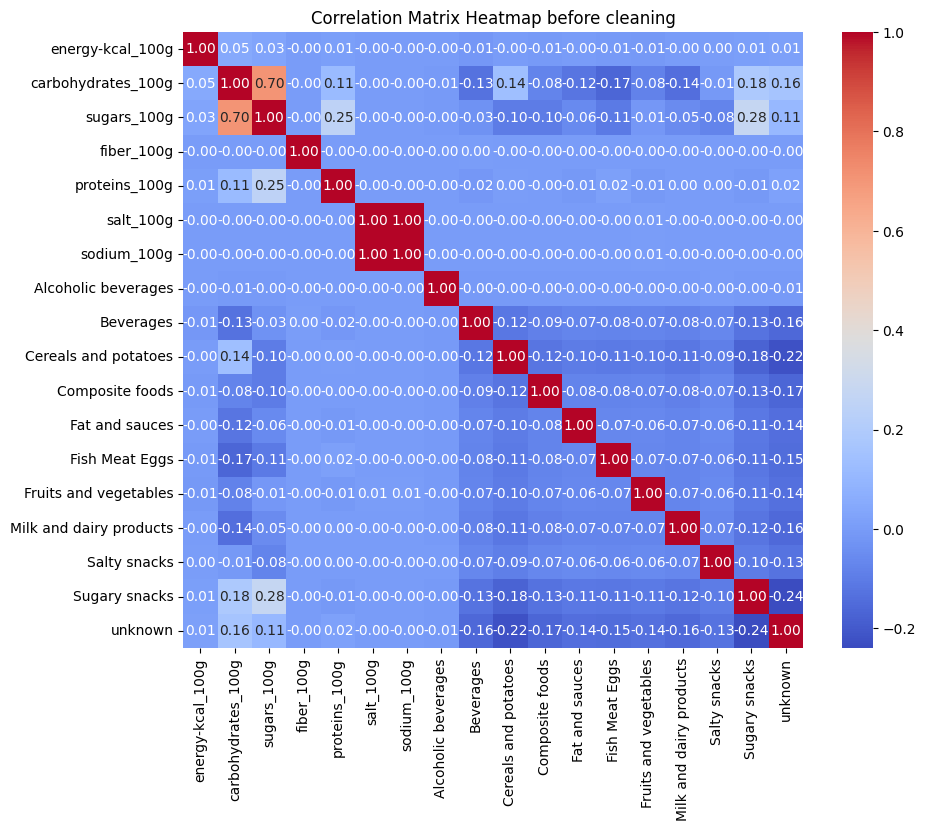

In [ ]:
#checking correltation between different features so that If there is any high correlation columns then just using them instead of both of them as they both contain similar kind of info
corr_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap before cleaning')
plt.show()


## Removing Highly Correlated Features (Threshold = 0.7)
We checked how strongly every pair of numeric columns moves together. If the absolute correlation between two columns is greater than 0.7, they’re basically telling the same story. Keeping both adds redundant information that can confuse the model and slow training. So we drop one column from each highly‑correlated pair. This trims the dataset, lowers noise, and helps the model focus on distinct, useful signals.

In [ ]:
#for dropping columns theshold is set to 0.7
threshold = 0.7
corr_matrix_abs = corr_matrix.abs()
upper_triangle = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

cols_to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > threshold)]
print("Columns to drop due to high correlation:", cols_to_drop)
df = df.drop(columns=cols_to_drop)
print("DataFrame shape after dropping columns:", df.shape)

Columns to drop due to high correlation: ['sugars_100g', 'sodium_100g']
DataFrame shape after dropping columns: (508778, 25)


/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


## Correlation Matrix After Cleaning


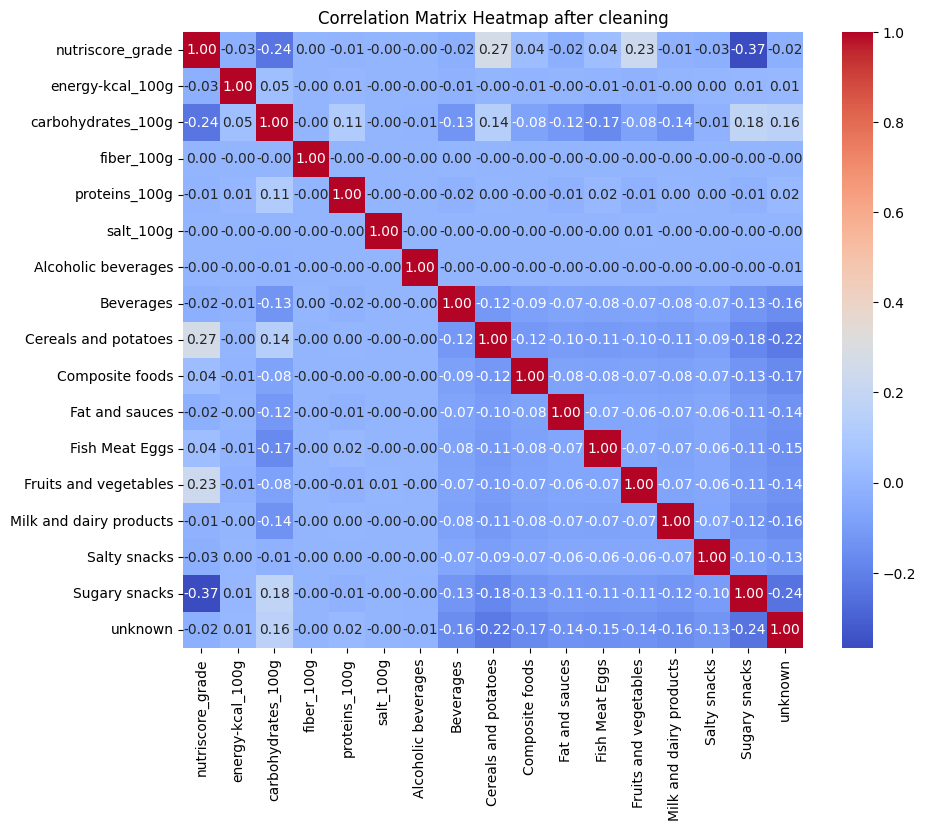

In [ ]:
numerical_columns=df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap after cleaning')
plt.show()


This updated heatmap shows that no pair of numeric features now has an extreme correlation. By removing the redundant columns identified earlier, we’ve kept only variables that provide distinct information.


In [ ]:
numerical_columns=df.select_dtypes(include=np.number).columns.tolist()

In [ ]:
new_df=df[numerical_columns]

## Boxplots
We drew boxplots for every continuous numeric column to spot outliers.

Original dataset shape: (508778, 17)


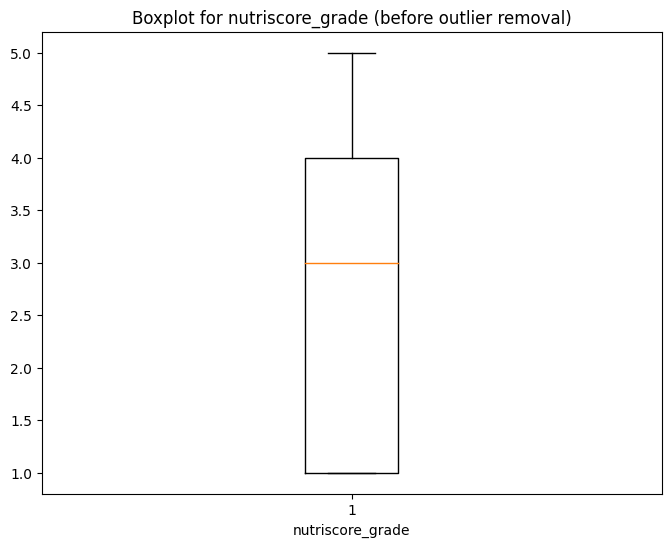

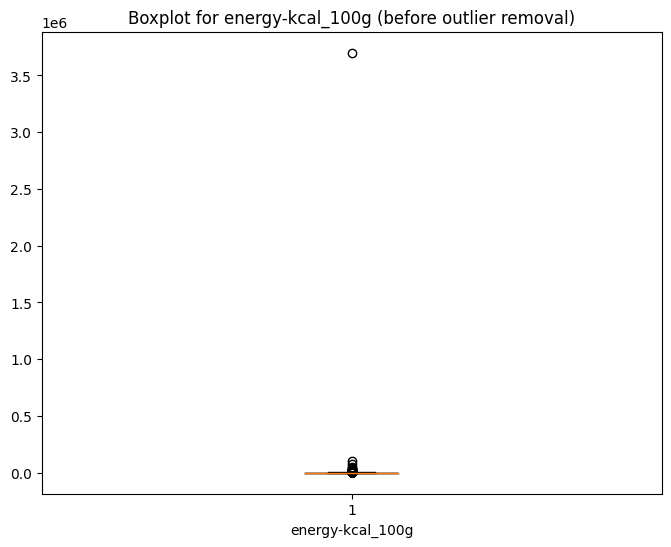

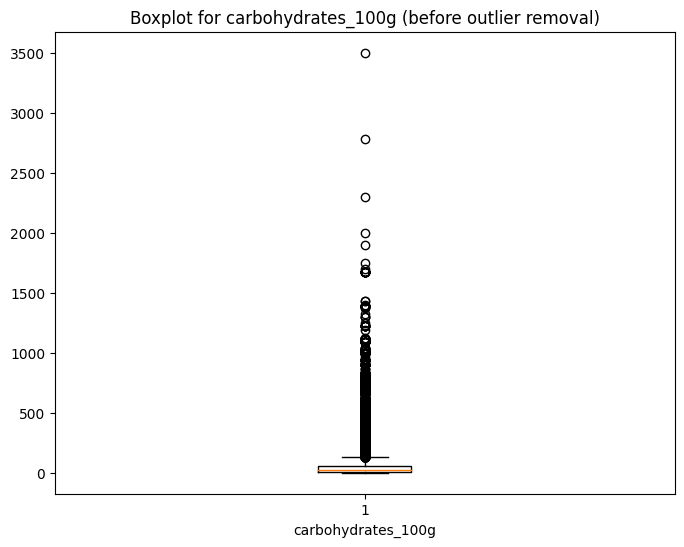

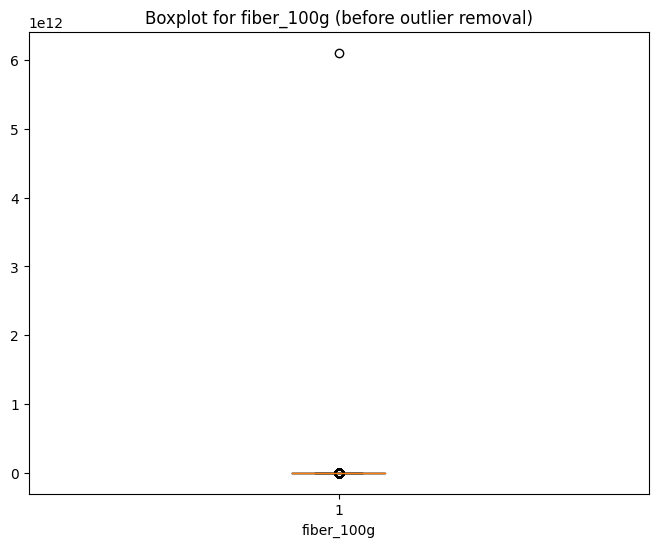

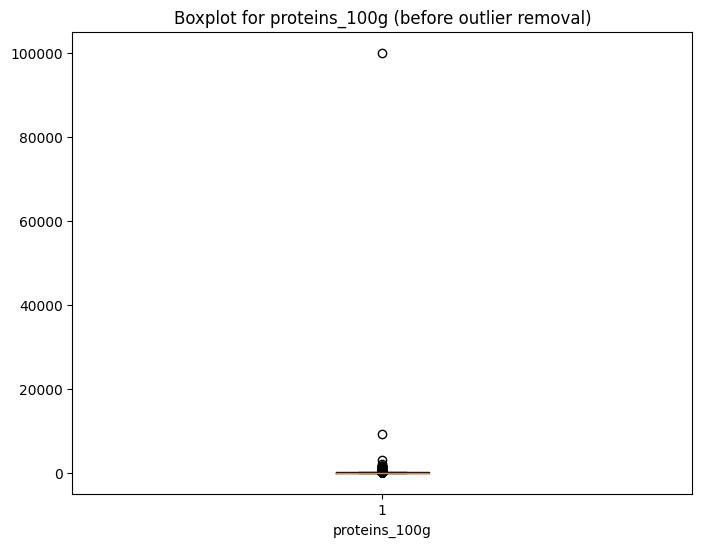

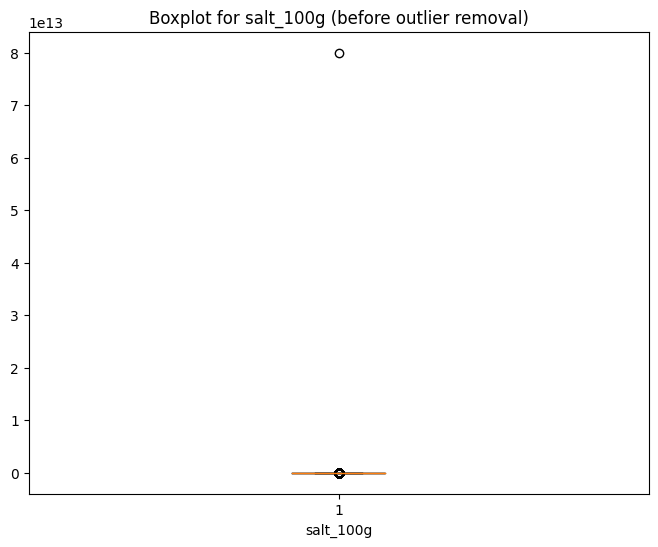

In [ ]:
#plotting box plot to see if there is any outlier is the non binary numerical columns
print("Original dataset shape:", new_df.shape)
numeric_cols=new_df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    if col not in encoded_columns:
        plt.figure(figsize=(8, 6))
        plt.boxplot(df[col].dropna())
        plt.title(f'Boxplot for {col} (before outlier removal)')
        plt.xlabel(col)
        plt.show()

In [ ]:
from scipy.stats import zscore



['nutriscore_grade', 'fiber_100g', 'energy-kcal_100g', 'carbohydrates_100g', 'salt_100g', 'proteins_100g']
Cleaned dataset shape: (502502, 17)


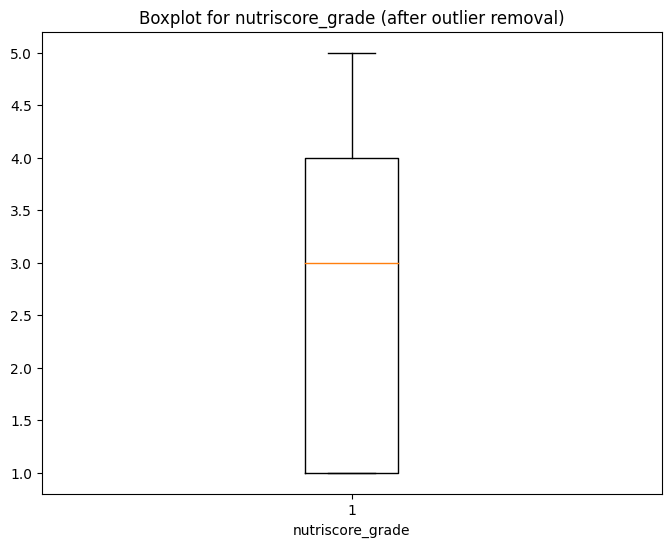

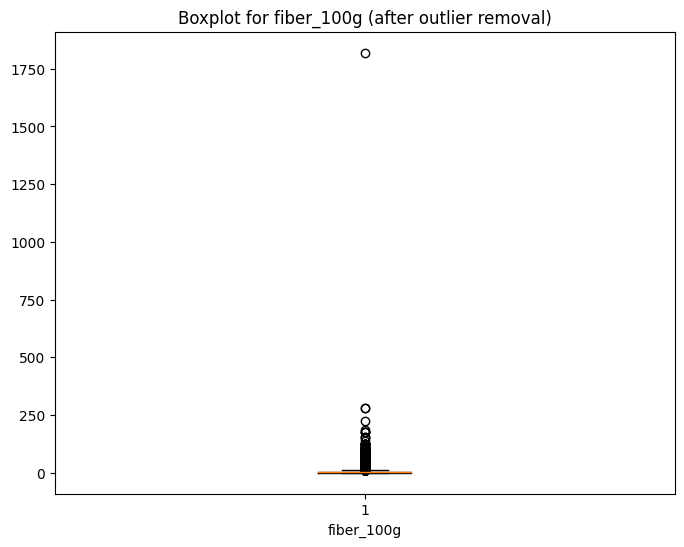

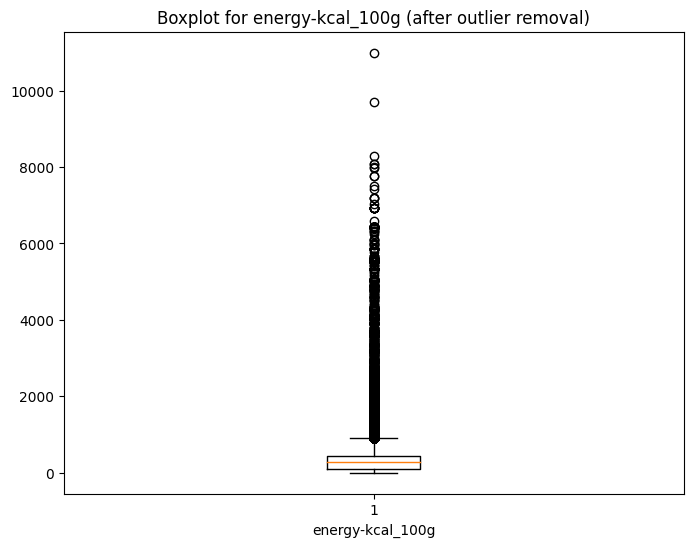

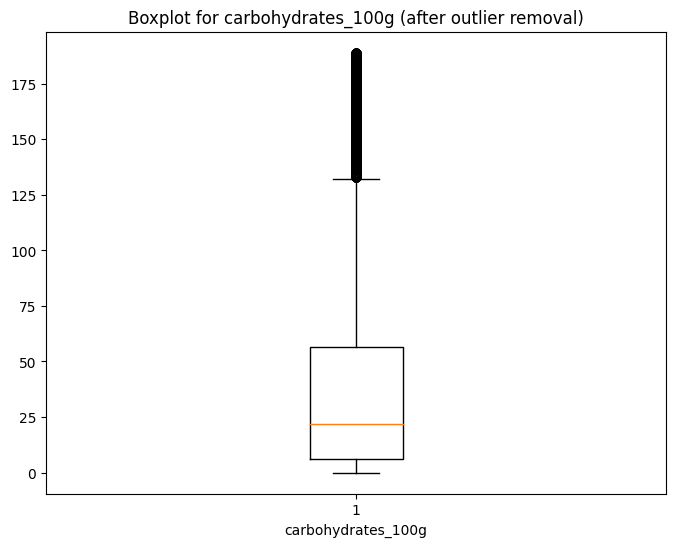

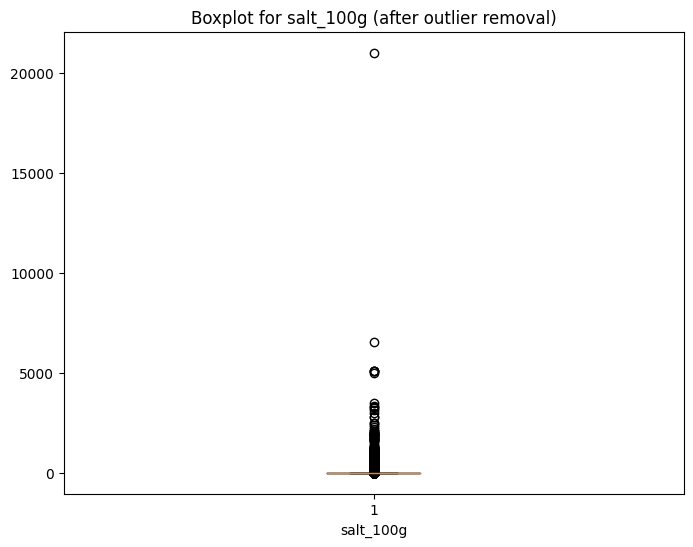

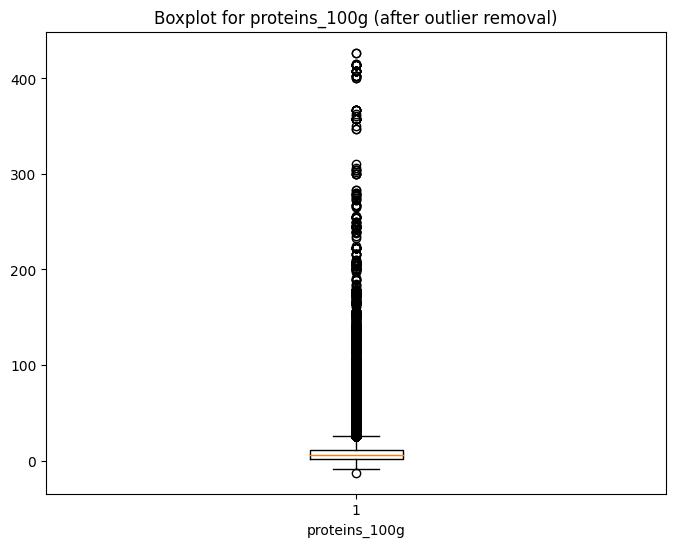

In [ ]:
#using zscore with threshold of 3 to remove the outlier from the columns
numeric_cols = new_df.select_dtypes(include=['number']).columns
numerical_cols = list(set(numeric_cols) - set(encoded_columns))
print(numerical_cols)
z_scores = np.abs(zscore(new_df[numerical_cols]))
threshold = 3
mask = (z_scores < threshold).all(axis=1)
df_cleaned = new_df[mask]
print("Cleaned dataset shape:", df_cleaned.shape)
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    plt.boxplot(df_cleaned[col].dropna())
    plt.title(f'Boxplot for {col} (after outlier removal)')
    plt.xlabel(col)
    plt.show()


In [ ]:
#dropping any row with null value in it
df_cleaned.dropna(inplace=True)

<ipython-input-25-459eac822594>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.dropna(inplace=True)


In [ ]:
df_cleaned.head()

,nutriscore_grade,energy-kcal_100g,carbohydrates_100g,fiber_100g,proteins_100g,salt_100g,Alcoholic beverages,Beverages,Cereals and potatoes,Composite foods,Fat and sauces,Fish Meat Eggs,Fruits and vegetables,Milk and dairy products,Salty snacks,Sugary snacks,unknown
0,3,335.0,7.5,2.2,2.3,0.4,0,0,0,0,1,0,0,0,0,0,0
1,2,100.0,26.0,3.0,1.0,0.0,0,0,0,0,0,0,0,0,0,0,1
2,2,376.0,6.7,2.9,82.0,1.7,0,0,1,0,0,0,0,0,0,0,0
3,3,1.0,1.0,1.0,1.0,1.0,0,0,0,0,0,0,1,0,0,0,0
4,5,16.0,2.0,88.0,1.0,0.3,0,0,0,0,0,0,0,0,0,0,1


# Defining the Target Variable
We set nutriscore_grade as the target_column because the main goal of this model is to predict a product’s Nutri‑Score based on its nutritional content and category information.

In [ ]:
target_column="nutriscore_grade"

In [ ]:
X = df_cleaned.drop(target_column, axis=1)
y = df_cleaned[target_column]
labels = sorted(np.unique(y))

# Normalize the dataset
StandardScaler rescales every numeric feature so that each has a mean of 0 and a standard deviation of 1. Putting all variables on the same scale prevents features with large numeric ranges from overpowering those with smaller ranges. Many algorithms such as SVMs, logistic regression, and neural networks—learn faster and perform more reliably when the input features are standardized in this way.

In [ ]:
feature_names = X.columns

# Normalize dataset using Standard Scaler function
scaler = StandardScaler()
X_normalized = pd.DataFrame(scaler.fit_transform(X), columns=feature_names)

# spliting dataset into train test split with 80% dataset used for training and rest for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42)

# Comparing Multiple Models
We used logistic regression, random forests , and support‑vector machines. For each model we measured accuracy, precision, recall, and F1‑score.


In [ ]:
#We are testing different model and how they perform on part of our dataset
# we are using logistic regression, random forest with varying number of estimators and support vector machine with different kernel
#we are using only 100k data
part_X_train = X_train[:100000]
part_y_train = y_train[:100000]

model_configs = {
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=42),
    'Random Forest (25 trees)': RandomForestClassifier(n_estimators=25, random_state=42),
    'Random Forest (10 trees)': RandomForestClassifier(n_estimators=10, random_state=42),
    'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', gamma='scale', probability=True, random_state=42),
}

results = []

for name, model in model_configs.items():
    model.fit(part_X_train, part_y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision (weighted)': precision,
        'Recall (weighted)': recall,
        'F1-Score (weighted)': f1,
        'Confusion Matrix': cm
    })

results_df = pd.DataFrame(results)



In [ ]:
#seeing the result of the model
print(results_df)

                      Model  Accuracy  Precision (weighted)  \
0       Logistic Regression  0.547716              0.527389   
1  Random Forest (25 trees)  0.781286              0.779410   
2  Random Forest (10 trees)  0.769833              0.767883   
3              SVM (Linear)  0.579477              0.520260   
4                 SVM (RBF)  0.634461              0.636531   

   Recall (weighted)  F1-Score (weighted)  \
0           0.547716             0.520885   
1           0.781286             0.779902   
2           0.769833             0.768535   
3           0.579477             0.544191   
4           0.634461             0.628789   

                                    Confusion Matrix  
0  [[21182, 1902, 1784, 327, 240], [7516, 7429, 6...  
1  [[22461, 2371, 449, 111, 43], [2907, 17542, 24...  
2  [[22443, 2393, 458, 109, 32], [3257, 17281, 23...  
3  [[18442, 4745, 2006, 0, 242], [4716, 11792, 60...  
4  [[19193, 4818, 879, 230, 315], [3677, 14779, 3...  


# Output
## Logistic Regression
This model achieved an accuracy of about 55%, with similar values for precision, recall, and F1-score. This relatively low performance suggests that the linear assumptions of logistic regression do not capture the complex patterns within our dataset.

## Random Forest (25 trees)
The Random Forest model using 25 decision trees performed the best, reaching around 78% accuracy and similarly high scores in precision, recall, and F1.

## Random Forest (10 trees)
With roughly 77% accuracy, the 10-tree version of Random Forest shows performance very close to its 25-tree counterpart, though slightly lower.

## SVM (Linear)
The Support Vector Machine with a linear kernel achieved about 58% accuracy with lower precision and F1-scores.

## SVM (RBF)
Using the RBF (Radial Basis Function) kernel, the SVM improves its performance, reaching around 63% accuracy.

After benchmarking several algorithms, the Random Forest with 25 trees delivered the strongest overall performance (highest accuracy, precision, recall, and F‑score). We therefore adopt it as our base learner for the next refinement step.
Next, we apply Recursive Feature Elimination (RFE) to systematically remove less important features, reducing our predictor set from 16 to the 10 most relevant ones. This not only simplifies the model, reducing the risk of over‑fitting and speeding up training, but also enhances interpretability by focusing on the most influential factors driving predictions.

In [ ]:
#as you can see in the above table Random forest with high number of estimators perform best so using it
#Using backward feature selection to use just 10 features out of 16
final_model = RandomForestClassifier(n_estimators=25, random_state=42)

rfe = RFE(estimator=final_model, n_features_to_select=10, step=1)
rfe.fit(X_train, y_train)
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)


In [ ]:
#selected features are use to retrain random forest classifier with estimator of size 50 i.e. around 50 decision trees are used.
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train_rfe, y_train)
y_pred = model.predict(X_test_rfe)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.821215709296425

Classification Report:
               precision    recall  f1-score   support

           1       0.89      0.90      0.90     25435
           2       0.81      0.80      0.80     23275
           3       0.77      0.77      0.77     22029
           4       0.75      0.68      0.71     12121
           5       0.84      0.88      0.86     17641

    accuracy                           0.82    100501
   macro avg       0.81      0.81      0.81    100501
weighted avg       0.82      0.82      0.82    100501



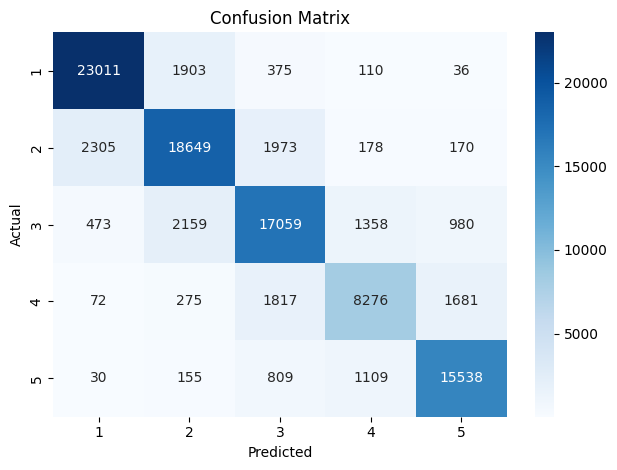

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=labels,yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


<H1>Sentiment analysis in amazon dataset</H1>

In [ ]:
import json
import pandas as pd

file_path = '/kaggle/working/Grocery_and_Gourmet_Food.jsonl'

data = []

with open(file_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 100:  # limit to top 100,000 records
            break
        record = json.loads(line)
        data.append(record)

review_df = pd.DataFrame(data)




In [ ]:
review_df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Excellent! Yummy!,Excellent!! Yummy! Great with other foods and...,[],B00CM36GAQ,B00CM36GAQ,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1587854482395,0,True
1,5.0,Delicious!!! Yum!,Excellent! The best! I use it with my beef a...,[],B074J5WVYH,B0759B7KLH,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1587854400380,0,True
2,5.0,"Extremely Delicious, but expensive imo",These are very tasty. They are extremely soft ...,[],B079TRNVHX,B079TRNVHX,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1587853224527,1,True
3,5.0,Delicious!,My favorite!,[],B07194LN2Z,B07194LN2Z,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1581313319614,0,True
4,5.0,Great taste,Great for making brownies and crinkle cookies.,[],B005CD4196,B005CD4196,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1581313294965,7,True


In [ ]:
import json
import pandas as pd

file_path = '/kaggle/working/Grocery_and_Gourmet_Food.jsonl'

rating_data = {1: [], 2: [], 3: [], 4: [], 5: []}
include_columns = ["rating", "title", "text", "helpful_vote", "verified_purchase"]

with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        record = json.loads(line)
        rating = record.get("rating")

        if rating in rating_data and len(rating_data[rating]) < 100000:
            filtered_record = {k: record[k] for k in include_columns if k in record}
            rating_data[rating].append(filtered_record)

        if all(len(lst) >= 100000 for lst in rating_data.values()):
            break

# Combine and shuffle the data
data = sum(rating_data.values(), [])
review_df = pd.DataFrame(data).sample(frac=1, random_state=42).reset_index(drop=True)




In [ ]:
print(f"Loaded {len(review_df)} reviews (20k per rating)")
print(review_df['rating'].value_counts())

Loaded 500000 reviews (20k per rating)
rating
2.0    100000
5.0    100000
3.0    100000
1.0    100000
4.0    100000
Name: count, dtype: int64


In [ ]:
review_df.dropna(inplace=True)

In [ ]:
review_df.drop_duplicates(inplace=True)

In [ ]:
review_df

,rating,title,text,helpful_vote,verified_purchase
0,2.0,It's okay,I wasn't overly impressed with this coffee. I...,0,False
1,2.0,Not for me unfortunately,Was not for me flavor wise.,0,True
2,2.0,Hard as a rock,Flavor was good. But it’s not a soft licorice.,0,True
3,2.0,Difference in two orders of the same .,Am not sure what difference is there between t...,5,True
4,5.0,Brings back childhood memories.,"Tastes great, really brings back memories.",0,True
...,...,...,...,...,...
499994,2.0,not so much,I got the variety box of the Numi garden varie...,0,True
499995,3.0,OK but expensive!,Good product but super expensive compared to f...,0,True
499997,2.0,"Dented,impossible packaging, burn popcorn.",Great looking. Arrived dented right on an area...,0,True
499998,2.0,Nasty not even close to the real thing.,"Nasty, save your money or get the real thing.",0,True


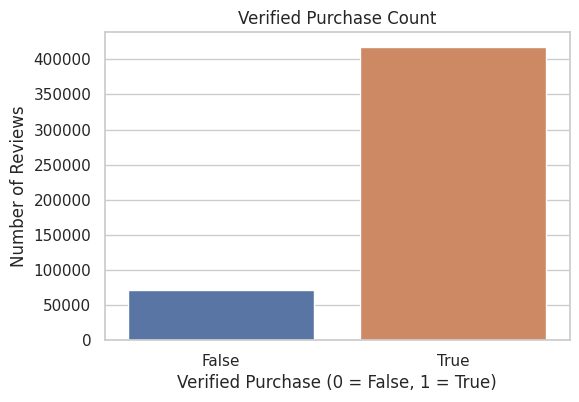

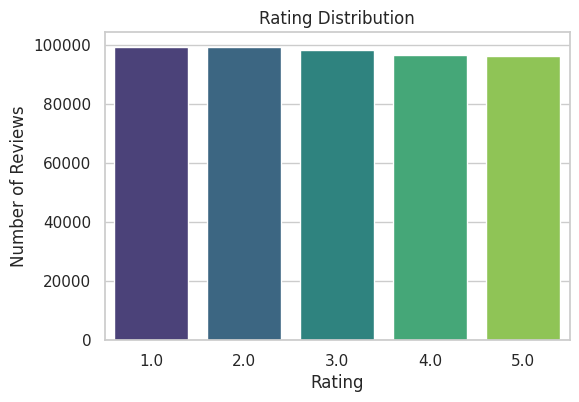

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


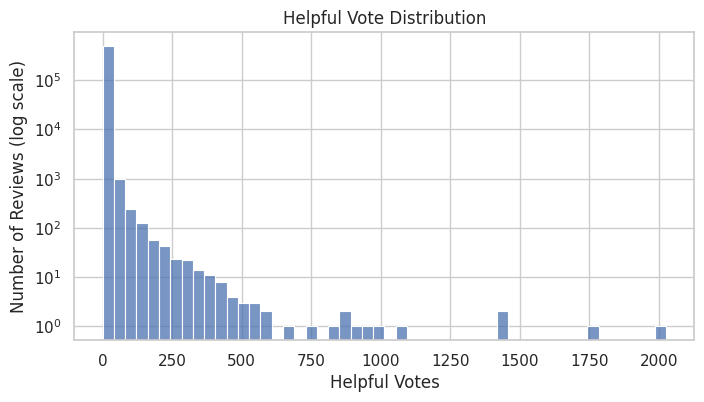

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style='whitegrid')

# === 1. Verified Purchase (Bar Plot)
plt.figure(figsize=(6, 4))
sns.countplot(x='verified_purchase', data=review_df)
plt.title('Verified Purchase Count')
plt.xlabel('Verified Purchase (0 = False, 1 = True)')
plt.ylabel('Number of Reviews')
plt.show()

# === 2. Ratings Distribution (Bar Plot)
plt.figure(figsize=(6, 4))
sns.countplot(x='rating', data=review_df, palette='viridis')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

# === 3. Helpful Vote Distribution (Histogram with log scale for skew)
plt.figure(figsize=(8, 4))
sns.histplot(review_df['helpful_vote'], bins=50, kde=False)
plt.yscale('log')
plt.title('Helpful Vote Distribution')
plt.xlabel('Helpful Votes')
plt.ylabel('Number of Reviews (log scale)')
plt.show()


## Rating Distribution
This bar plot shows how many reviews fall into each star‑rating category (1 to 5). The bars are almost the same height—about 95 k‑100 k reviews each—so the dataset is well balanced across ratings.

## Helpful Vote Distribution
The histogram displays how many “helpful” votes each review received. Because most reviews get very few votes while a tiny fraction accumulate hundreds or even thousands, the y‑axis is plotted on a log scale to make the long tail visible. The steep drop‑off after just a handful of votes highlights an extreme right‑skew: the vast majority of reviews have fewer than 10 helpful votes, and only outliers exceed 500.

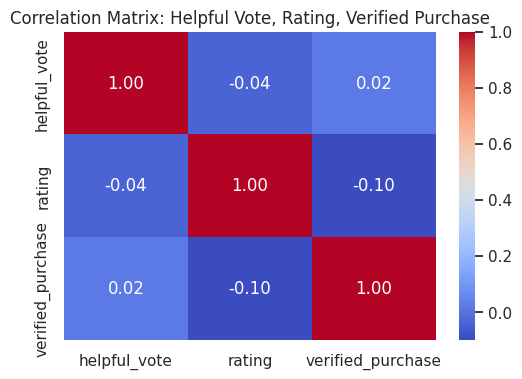

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Subset of relevant numeric columns
corr_df = review_df[['helpful_vote', 'rating', 'verified_purchase']]

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Helpful Vote, Rating, Verified Purchase')
plt.show()


## Correlation Matrix
This heatmap shows the linear relationships among three key variables.
It confirms that none of these features is strongly collinear, so each can be retained in the model without risking multicollinearity.

                     rating  helpful_vote
verified_purchase                        
False              3.319935      0.934589
True               2.923796      1.389584


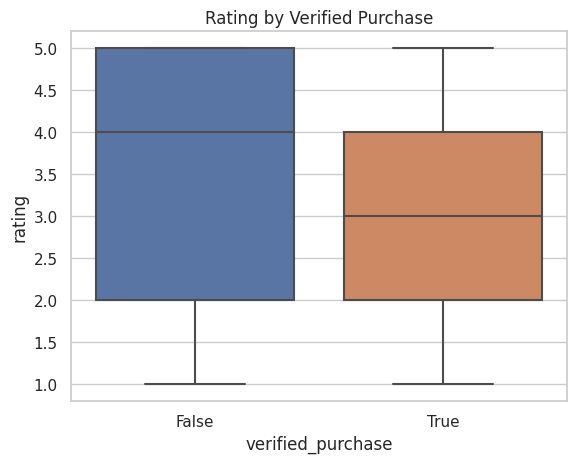

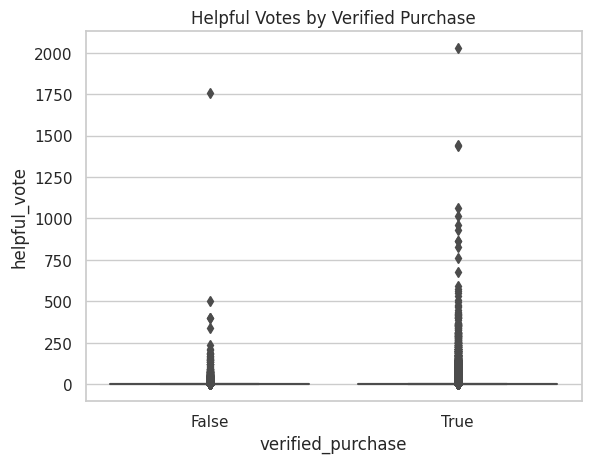

In [ ]:

group_stats =review_df.groupby('verified_purchase')[['rating', 'helpful_vote']].mean()
print(group_stats)
sns.boxplot(x='verified_purchase', y='rating', data=review_df)
plt.title("Rating by Verified Purchase")
plt.show()

sns.boxplot(x='verified_purchase', y='helpful_vote', data=review_df)
plt.title("Helpful Votes by Verified Purchase")
plt.show()

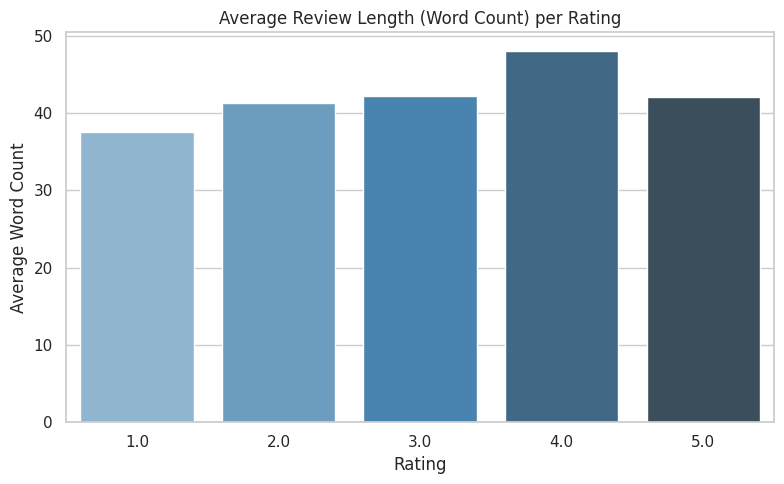

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

review_df['word_count'] = review_df['text'].apply(lambda x: len(str(x).split()))
mean_word_count = review_df.groupby('rating')['word_count'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='rating', y='word_count', data=mean_word_count, palette='Blues_d')
plt.title("Average Review Length (Word Count) per Rating")
plt.xlabel("Rating")
plt.ylabel("Average Word Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


The bar chart plots the average word count of reviews for each star rating. A clear upward trend emerges from 1‑star through 4‑star reviews: dissatisfied customers write the shortest comments (≈ 37 words on average), while 4‑star reviewers are the most verbose at roughly 48 words. Interestingly, the average length dips slightly for perfect 5‑star ratings (≈ 42 words), suggesting that highly satisfied buyers often keep their praise concise, whereas those who are almost—but not entirely—satisfied feel the need to elaborate. This pattern is useful for modelling because it hints that review length itself may carry sentiment information and could serve as an additional predictive feature.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('punkt', download_dir='/kaggle/working/nltk_data')
nltk.download('stopwords', download_dir='/kaggle/working/nltk_data')
nltk.download('wordnet', download_dir='/kaggle/working/nltk_data')
nltk.download('omw-1.4', download_dir='/kaggle/working/nltk_data')  # needed for wordnet lemmatizer sometimes



[nltk_data] Downloading package punkt to /kaggle/working/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /kaggle/working/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /kaggle/working/nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /kaggle/working/nltk_data...


True

In [ ]:
import zipfile
import os

# Paths
corpora_path = "/kaggle/working/nltk_data/corpora"

# Unzip wordnet
with zipfile.ZipFile(os.path.join(corpora_path, "wordnet.zip"), 'r') as zip_ref:
    zip_ref.extractall(corpora_path)

# Unzip stopwords
with zipfile.ZipFile(os.path.join(corpora_path, "stopwords.zip"), 'r') as zip_ref:
    zip_ref.extractall(corpora_path)

# Unzip omw-1.4 (needed by lemmatizer sometimes)
with zipfile.ZipFile(os.path.join(corpora_path, "omw-1.4.zip"), 'r') as zip_ref:
    zip_ref.extractall(corpora_path)

In [ ]:
nltk.data.path.append('/kaggle/working/nltk_data')  # Tell NLTK to look here


In [ ]:


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    tokens = word_tokenize(text)
    tokens_no_stopwords = [word for word in tokens if word not in stop_words]
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens_no_stopwords]
    cleaned_text = ' '.join(lemmatized_tokens)
    return cleaned_text


Lower‑casing and punctuation removal standardise the text, stop‑word filtering discards high‑frequency filler words that carry little sentiment, and lemmatisation collapses different grammatical forms to a common root. Together these steps shrink the vocabulary, reduce sparsity, and highlight the truly informative tokens.

In [ ]:
!pip install swifter
import swifter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.8 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16507 sha256=62ec086af070c00f358485953653dff7d9144fb7fd45bb4feea20c01861a5183
  Stored in directory: /root/.cache/pip/wheels/e4/cf/51/0904952972ee2c7aa3709437065278dc534ec1b8d2ad41b443
Successfully built swifter


In [ ]:


review_df['cleaned_text'] = review_df['text'].swifter.apply(preprocess_text)
print(review_df[['text', 'cleaned_text']].head())

Pandas Apply:   0%|          | 0/489488 [00:00<?, ?it/s]

                                                text  \
0  I wasn't overly impressed with this coffee.  I...   
1                        Was not for me flavor wise.   
2     Flavor was good. But it’s not a soft licorice.   
3  Am not sure what difference is there between t...   
4         Tastes great, really brings back memories.   

                                        cleaned_text  
0  wasnt overly impressed coffee doesnt really sm...  
1                                        flavor wise  
2                          flavor good soft licorice  
3  sure difference last batch ordered refused tur...  
4              taste great really brings back memory  


The goal of using TF‑IDF is to convert unstructured text into a numeric form that captures the importance of each word. Instead of treating every word equally, TF‑IDF measures each term’s frequency in a specific review while reducing the weight of words that appear in many reviews . Limiting the features to the top 100 helps reduce noise and dimensionality.

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer


vectorizer = TfidfVectorizer(stop_words='english', max_features=100)
tfidf_matrix = vectorizer.fit_transform(review_df['cleaned_text'])


tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())



We combined the review metadata with the text-derived TF‑IDF features and normalized the verified purchase indicator so that our model can learn from the complete picture. By merging these sources, the model benefits from both the structured data (rating, helpful vote count, verified status) and the semantic information hidden in the text. Converting the verified_purchase column to a binary format ensures consistency and ease of use during training, ultimately contributing to a more robust and interpretable model.

In [ ]:
new_review_df = pd.concat([review_df[['rating', 'helpful_vote',"verified_purchase"]].reset_index(drop=True), tfidf_df], axis=1)

print(new_review_df.head())

   rating  helpful_vote  verified_purchase  add  amazon  bad  bag  best  \
0     2.0             0              False  0.0     0.0  0.0  0.0   0.0   
1     2.0             0               True  0.0     0.0  0.0  0.0   0.0   
2     2.0             0               True  0.0     0.0  0.0  0.0   0.0   
3     2.0             5               True  0.0     0.0  0.0  0.0   0.0   
4     5.0             0               True  0.0     0.0  0.0  0.0   0.0   

   better  bit  ...  tried  try  use  used  want  water  way  wont  work  year  
0     0.0  0.0  ...    0.0  0.0  0.0   0.0   0.0    0.0  0.0   0.0   0.0   0.0  
1     0.0  0.0  ...    0.0  0.0  0.0   0.0   0.0    0.0  0.0   0.0   0.0   0.0  
2     0.0  0.0  ...    0.0  0.0  0.0   0.0   0.0    0.0  0.0   0.0   0.0   0.0  
3     0.0  0.0  ...    0.0  0.0  0.0   0.0   0.0    0.0  0.0   0.0   0.0   0.0  
4     0.0  0.0  ...    0.0  0.0  0.0   0.0   0.0    0.0  0.0   0.0   0.0   0.0  

[5 rows x 103 columns]


In [ ]:
def map_verified(x):
    if pd.isna(x):
        return np.nan
    return 1 if str(x).strip().lower() == 'true' else 0
new_review_df['verified_purchase'] = new_review_df['verified_purchase'].apply(map_verified)


In [ ]:
new_review_df.head()

,rating,helpful_vote,verified_purchase,add,amazon,bad,bag,best,better,bit,...,tried,try,use,used,want,water,way,wont,work,year
0,2.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.0,5,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score,accuracy_score


We isolate the target variable (rating) from the rest of the features to set up our supervised learning workflow.

In [ ]:
target_column="rating"
X = new_review_df.drop(target_column, axis=1)
y = new_review_df[target_column]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

We use logistic regression as a baseline model because it is simple, interpretable, and efficient for predicting our target variable (rating).

In [ ]:
lr_model = LogisticRegression(max_iter=1000, n_jobs=-1)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, n_jobs=-1)

In [ ]:
#predicting the output on test data
y_pred_rbf = lr_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_rbf)
precision = precision_score(y_test, y_pred_rbf, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred_rbf, average='weighted', zero_division=1)
f1 = f1_score(y_test, y_pred_rbf, average='weighted', zero_division=1)


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.3952787595252201
Precision: 0.38624794785645244
Recall: 0.3952787595252201
F1 Score: 0.3815064870966798


The results show that our model gets the correct rating only about 39.5% of the time.

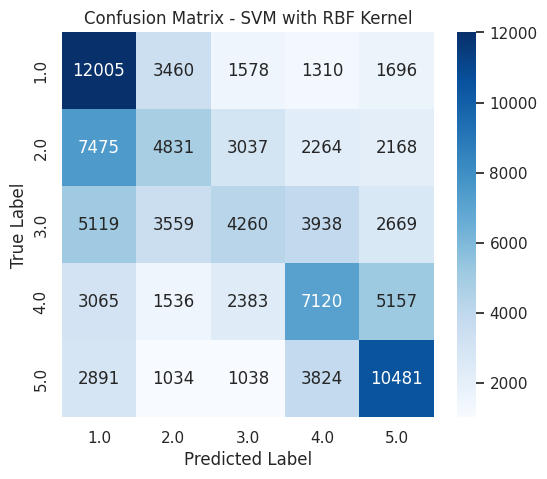

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get unique labels in sorted order
labels = sorted(np.unique(y))

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_rbf, labels=labels)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM with RBF Kernel")
plt.show()


Accuracy: 0.3655232997609757
Precision: 0.36866228176576277
Recall: 0.3655232997609757
F1 Score: 0.3647334234838242


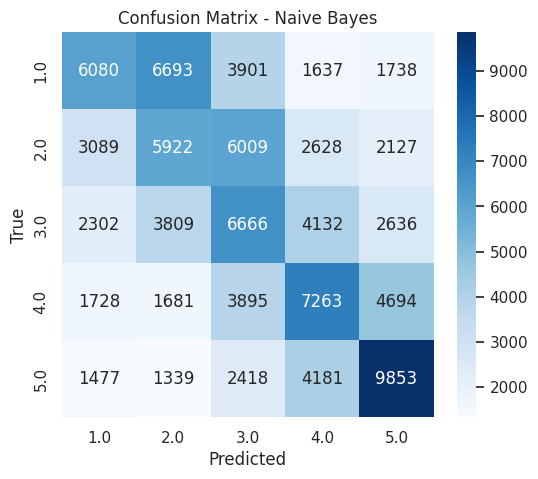

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, average='weighted', zero_division=1))
print("Recall:", recall_score(y_test, y_pred_nb, average='weighted', zero_division=1))
print("F1 Score:", f1_score(y_test, y_pred_nb, average='weighted', zero_division=1))

# Confusion Matrix
labels = sorted(np.unique(y_test))
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


We use the Naive Bayes method here because it is well‑suited for text data and high‑dimensional features. After training the model, we evaluate its performance using common metrics (accuracy, precision, recall, and F1-score) to understand how well the model predicts ratings.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svc = SVC()
grid = GridSearchCV(svc, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best score:", grid.best_score_)
best_params = grid.best_params_

best_svc = SVC(**best_params)
best_svc.fit(X_train, y_train)

y_pred_best = best_svc.predict(X_test)

from sklearn.metrics import classification_report
print("Classification Report:\n", classification_report(y_test, y_pred_best))


## How do sugar and fat levels vary with Nutri-Score grades?

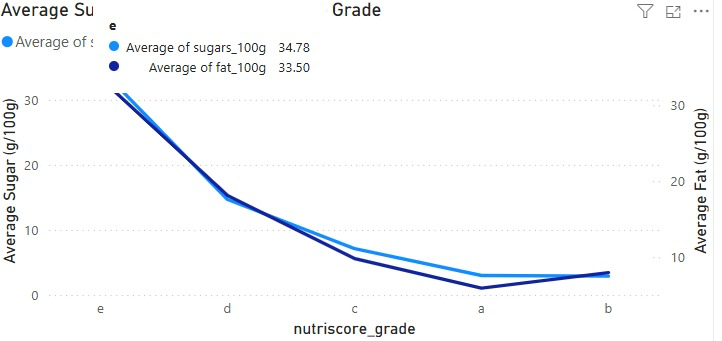

Clear downward trend from Nutri-Score E to A.

"E"-rated products have the highest average sugar and fat values.

Confirms that Nutri-Score strongly aligns with high fat/sugar contents.

## Are commonly consumed or assumed "healthy" products actually healthy?


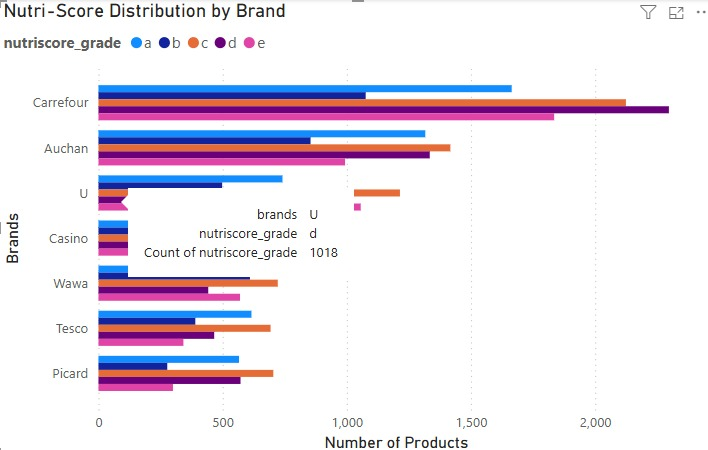

Despite expectations, Ice Cream is heavily skewed toward Nutri-Score "E", confirming poor health value.

Peanut Butter shows a more balanced distribution.

Spaghetti has many "A" grades, indicating it's generally seen as healthy when not overly processed.

## Which brands offer the most products, and how healthy are they?
Carrefour and Auchan have the largest product offerings.

But brands like Carrefour have a large portion of "E"-grade products, indicating many low-nutrition items.

You can compare brands not just by volume but by health quality.

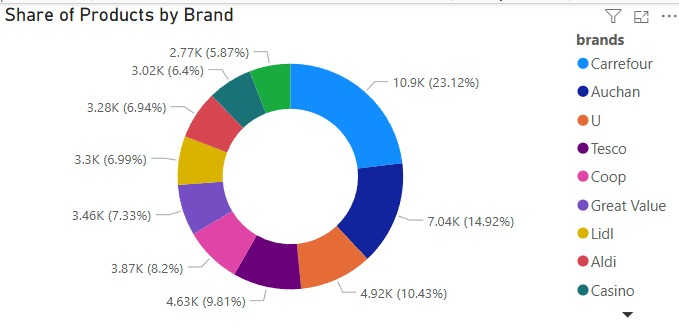

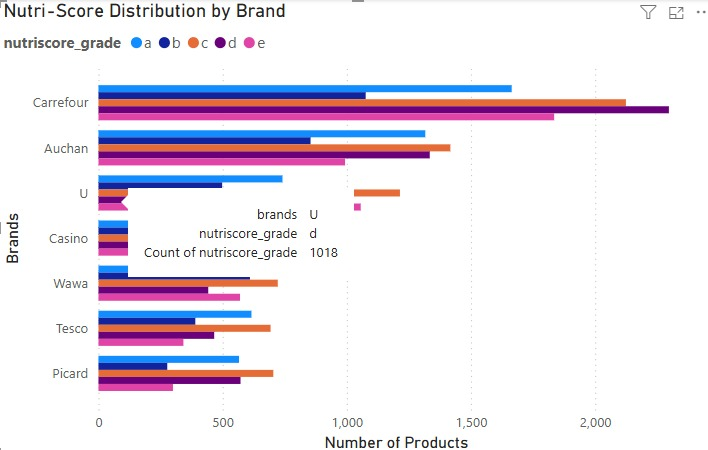